# **ETTh1 | Multi-to-Univariate_One-Shot Forecasting of OT**
---

In [1]:
# Package-specific imports
from utils.data_utils import data_import, data_prep
from utils.data_loader import create_batches
from utils.training import model_training
from utils.evaluation import model_test, plot_test_results
from models.lstm_model import LSTM_ForecastModel

# General imports
import torch
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd


#### **Setting Key Parameters**

In [2]:
# Hyperparameter definition w/o Optuna tuning -- can be added later
context_length  = 96       # [hours]
forecast_length = 16       # [hours]
batch_size      = 64       # [samples]
lstm_width      = 48
lstm_depth      = 1
dropout         = 0.1
optimizer_learningrate = 0.0001
max_epochs      = 100
patience_epochs = 15

----
## **INITIALIZATION**
----

#### **Importing the Dataset**

In [3]:
# Set link to original dataset
url_ETTh1 = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv"

# Import full data set from original source
ETTh1_data_df = data_import(url_ETTh1)

#### **Split, Scale, and Batch Data**
- Chosing the MinMaxScaler over the StandardScaler because it allows to bound all signals to a fixed interval of magnitudes: no channel shall introduce overfitting due to pure differences in magnitude --> feels "cleaner" for multivariate inputs.
- Choosing (-1,1) as interval for the MinMaxScaler for neutral signal processing
- Using the typical ETT 12 - 4 - 4 split, resulting in a total of 20 months of data
- The dataset contains almost 24 months, so the remaining c. 4 months get cut and are **discarded**
- Validation and test datasets are extended so that x_val and x_test start in the training and validation set already

In [4]:
# Set up the scaler
scaler = MinMaxScaler(feature_range=(-1, 1))

In [5]:
# Split and scale data
prepared_data = data_prep(
    source_data         = ETTh1_data_df,
    train_length_months = 12,
    vali_length_months  = 4,
    test_length_months  = 4,
    context_length      = context_length,
    scaler              = scaler
)

# Extract the dictionary containing the scalers for each input data channel
scalers_dict = prepared_data[3]

# Create samples and batches
batched_data = create_batches(
    prepared_data    = prepared_data,
    context_length   = context_length,
    forecast_length  = forecast_length,
    batch_size       = batch_size,
    training_shuffle = True
)

Timesteps in the source dataset:  17420 hours
Timesteps in the truncated split:  14400 hours
Timesteps in the training split:  8640 hours
Timesteps in the discarded split:  3020 hours
The training/validation/test split relative to the truncated set [%]:  60.0 / 20.0 / 20.0
x_inputs batch shape: torch.Size([64, 96, 7])
y_targets batch shape: torch.Size([64, 16])
Number of training batches: 134
Number of test batches: 45


In [6]:
# Initialize the model
model = LSTM_ForecastModel(
    num_input_features = ETTh1_data_df.shape[1],  # columns in the input dataframe
    lstm_width         = lstm_width,
    lstm_depth         = lstm_depth,
    forecast_length    = forecast_length,
    dropout            = dropout
)

# Print number of trainable parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model has {num_params} trainable parameters.")


Model has 11728 trainable parameters.


/home/johannes/Dokumente/_Arbeit/TUB Summer School/My Project Files/DL4TS/.venv/lib/python3.13/site-packages/torch/nn/modules/rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


----
## **TRAINING**
----

- for a clean re-training run with default parameters and random seeds, re-initialize the model above

In [ ]:
# Run the training loop to find the best-performing internal states of the model
best_states_dict = model_training(
    model                  = model,
    data_batches           = batched_data,
    max_epochs             = max_epochs,
    patience_epochs        = patience_epochs,
    optimizer_learningrate = optimizer_learningrate
)

In [ ]:
# Save the best model parameters
torch.save(model.state_dict(best_states_dict), "LSTM_1x48_weights.pt")

----
## **TEST & EVALUATION**
----

In [9]:
# Optional loading of states dicts - avoiding retraining
loaded_states_dict = torch.load("LSTM_1x48_weights.pt")

In [10]:
# Run the test
test_results = model_test(
    model = model,
    best_state_dict = loaded_states_dict,
    data_batches = batched_data,
    scalers_dict = scalers_dict,
)

Device: cpu

Test MSE: 7.12407589
Test MAE: 2.19921494


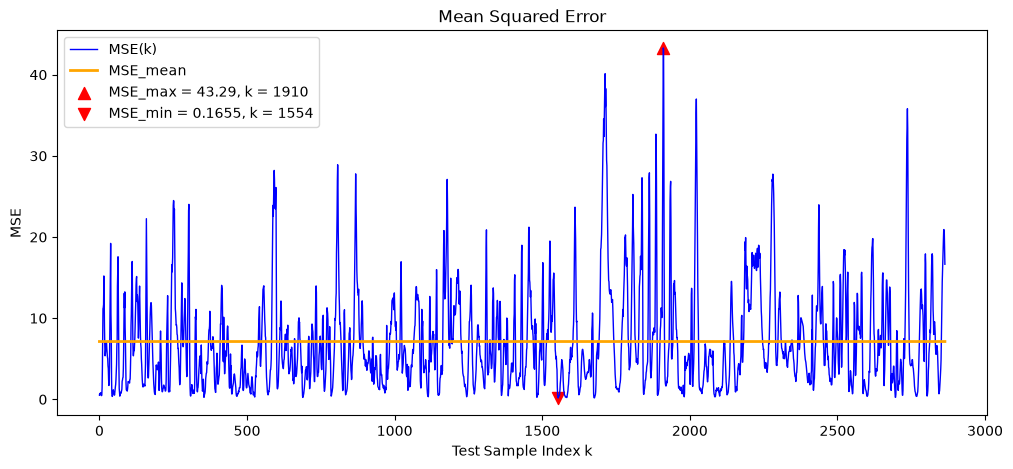

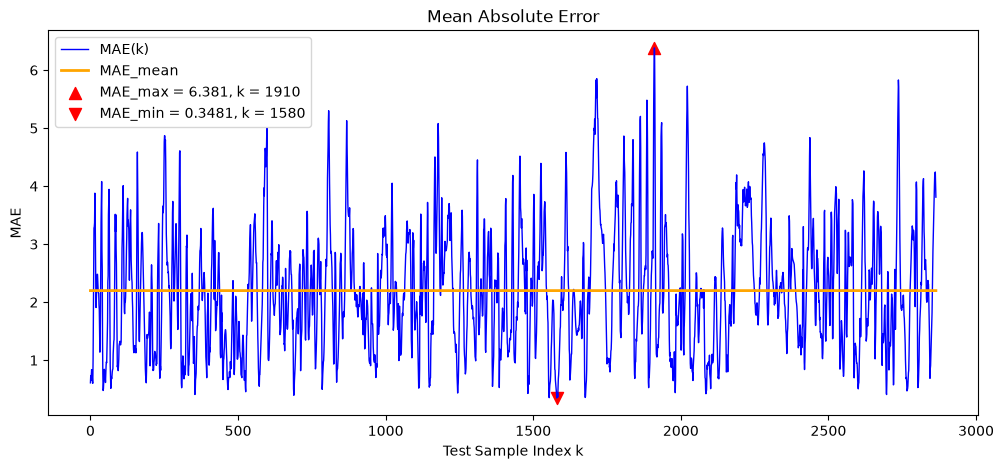

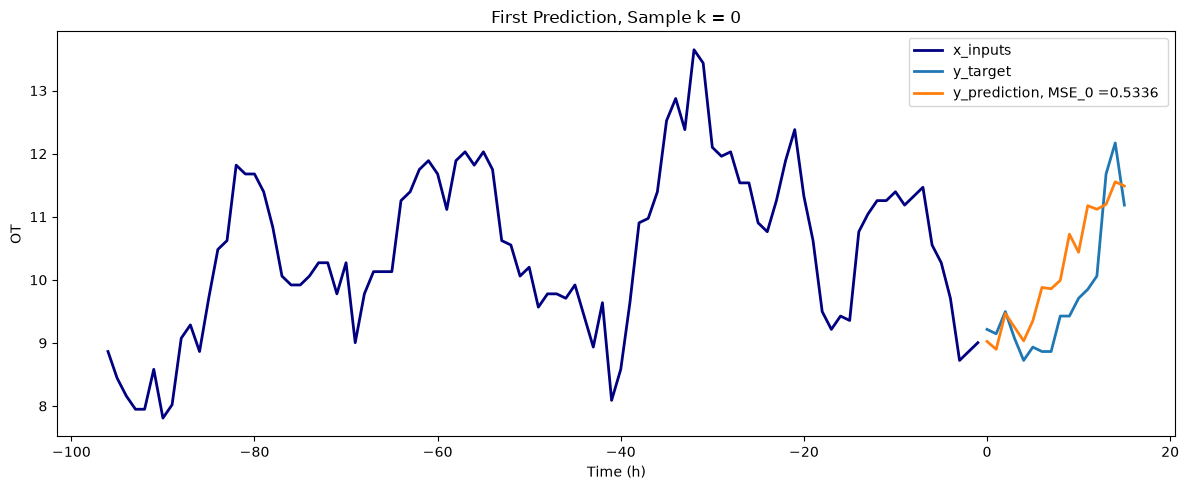

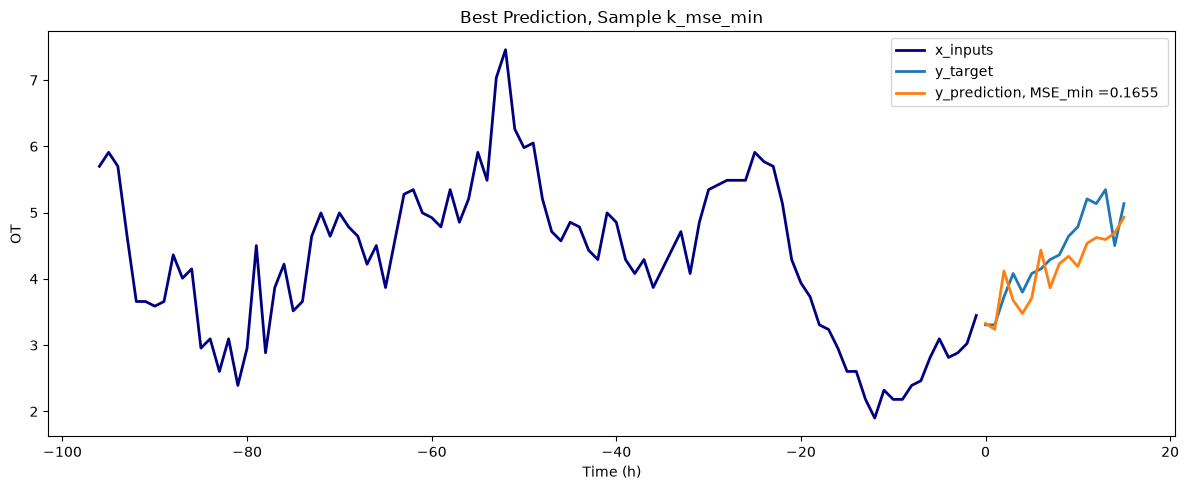

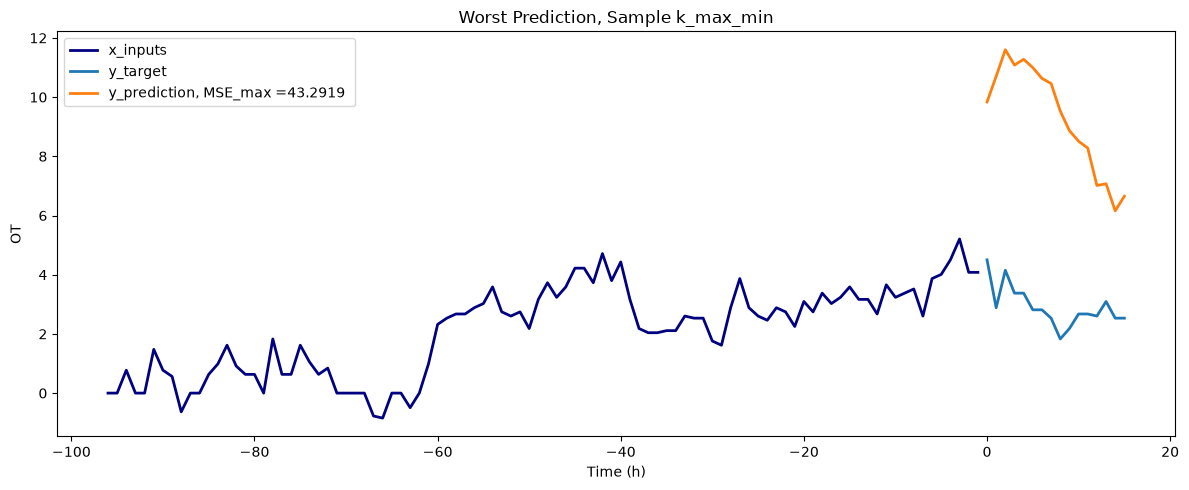

In [11]:
# Plot the results
plot_test_results(
    prepared_data   = prepared_data,
    test_results    = test_results,
    context_length  = context_length,
    forecast_length = forecast_length
)